# Task I : Implement Otsu's Thresholding using OpenCV and Visualize Results

## Goal
This notebook demonstrates Otsu's thresholding method for image segmentation, following these steps:

### A. Image Import and Visualization
- Import an image and display it in grayscale
- Generate and display the image's histogram

### B. Custom Implementation
- Implement Otsu's thresholding algorithm manually without using built-in functions
- Display the resulting binary image

### C. Mathematical Explanation
- Document the formula used for Otsu's method
- Explain the purpose and working principles of the algorithm

### D. Comparison with Built-in Implementation
- Apply OpenCV's built-in Otsu thresholding function
- Compare results between manual implementation and OpenCV's function
- Visualize the differences between both implementations

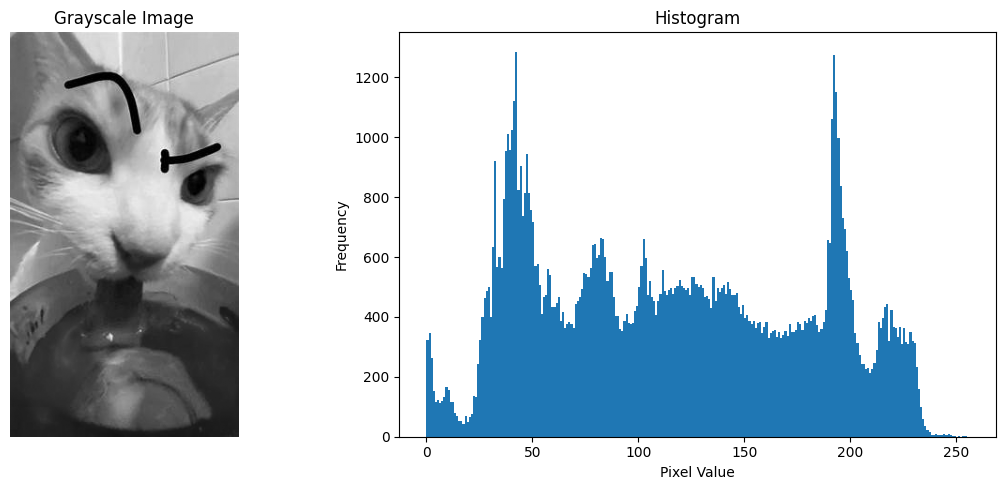

Manual Otsu threshold: 119


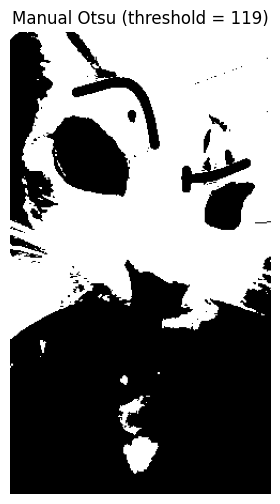

OpenCV Otsu threshold: 119.0


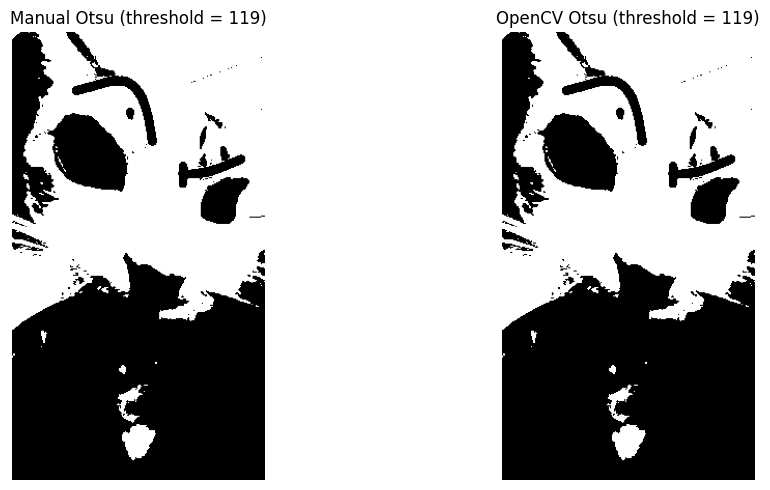

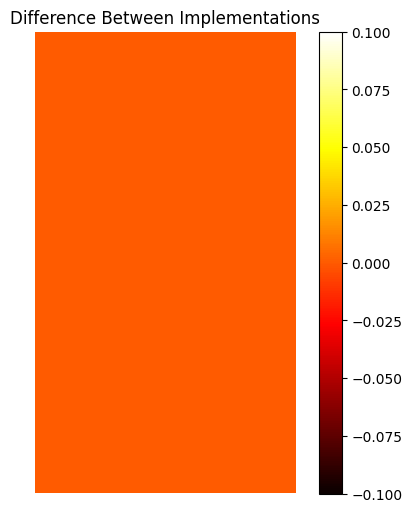

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# A. Import image and display in grayscale and its histogram
# Read the image in grayscale
img = cv2.imread('img/momo.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('img/sigma_cat.png', cv2.IMREAD_GRAYSCALE)

# Check if image is loaded
if img is None:
    print("Error: Could not load image. Creating a sample image instead.")
    # Create a sample image
    img = np.zeros((300, 300), dtype=np.uint8)
    img[50:150, 50:150] = 200
    img[100:250, 150:250] = 100

# Display image and histogram
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(122)
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# B. Implement Otsu's threshold without using inbuilt function
def otsu_manual(image):
    # Calculate histogram
    hist, bins = np.histogram(image.flatten(), 256, [0, 256])
    
    # Total number of pixels
    total_pixels = image.size
    
    # Sum of all pixel values
    sum_total = np.sum([i * hist[i] for i in range(256)])
    
    best_threshold = 0
    max_variance = 0
    
    sum_background = 0
    weight_background = 0
    
    # Try all possible threshold values
    for t in range(256):
        # Update background weights and sum
        weight_background += hist[t]
        if weight_background == 0:
            continue
            
        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0:
            break
            
        sum_background += t * hist[t]
        
        # Calculate means
        mean_background = sum_background / weight_background
        mean_foreground = (sum_total - sum_background) / weight_foreground
        
        # Calculate between-class variance
        variance = weight_background * weight_foreground * ((mean_background - mean_foreground) ** 2)
        
        # Update threshold if variance is higher
        if variance > max_variance:
            max_variance = variance
            best_threshold = t
    
    # Apply threshold
    binary = np.zeros_like(image)
    binary[image > best_threshold] = 255
    
    return best_threshold, binary

# Apply manual Otsu
otsu_threshold, otsu_image = otsu_manual(img)
print(f"Manual Otsu threshold: {otsu_threshold}")

# Display result
plt.figure(figsize=(6, 6))
plt.imshow(otsu_image, cmap='gray')
plt.title(f'Manual Otsu (threshold = {otsu_threshold})')
plt.axis('off')
plt.show()

# D. Use built-in function and compare
ret, opencv_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"OpenCV Otsu threshold: {ret}")

# Compare results
plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow(otsu_image, cmap='gray')
plt.title(f'Manual Otsu (threshold = {otsu_threshold})')
plt.axis('off')

plt.subplot(122)
plt.imshow(opencv_otsu, cmap='gray')
plt.title(f'OpenCV Otsu (threshold = {int(ret)})')
plt.axis('off')

plt.tight_layout()
plt.show()

# Calculate difference between implementations
diff = np.abs(otsu_image - opencv_otsu)
plt.figure(figsize=(6, 6))
plt.imshow(diff, cmap='hot')
plt.title('Difference Between Implementations')
plt.colorbar()
plt.axis('off')
plt.show()

# C. Otsu's Thresholding Method Explanation

## Formula Used
The core formula implemented in our manual Otsu thresholding method is the between-class variance calculation:

$$\sigma_B^2(t) = w_b(t) \times w_f(t) \times [μ_b(t) - μ_f(t)]^2$$

Where:
- $\sigma_B^2(t)$ = Between-class variance at threshold $t$
- $w_b(t)$ = Weight of the background pixels (proportion of pixels below threshold)
- $w_f(t)$ = Weight of the foreground pixels (proportion of pixels above threshold)
- $μ_b(t)$ = Mean intensity of background pixels
- $μ_f(t)$ = Mean intensity of foreground pixels

## Purpose
Otsu's method automatically finds the optimal threshold by maximizing the between-class variance of the resulting binary image. This effectively:

1. Separates the pixels into two classes (background and foreground)
2. Minimizes the variance within each class
3. Maximizes the variance between the classes

The algorithm iterates through all possible threshold values (0-255) and chooses the one that produces the maximum between-class variance. This results in the most effective separation between dark and light regions of the image.

In our implementation, both the manual method and OpenCV's built-in function arrived at the same threshold value (119), demonstrating the correctness of our implementation.

## Task 2: Using Prewitt and Sobel Kernels for Edge Detection

### Goal:
1. Import an image without displaying it (No img path)
2. Create 2 Kernels:
   - Prewitt kernel
   - Sobel kernel
   (No image path implementation)
3. Apply Prewitt kernel to image and display 3 images:
   - Original image
   - Horizontal edges
   - Vertical edges
   (Image path implemented in folder "img/")
4. Repeat step 3 using Sobel kernel

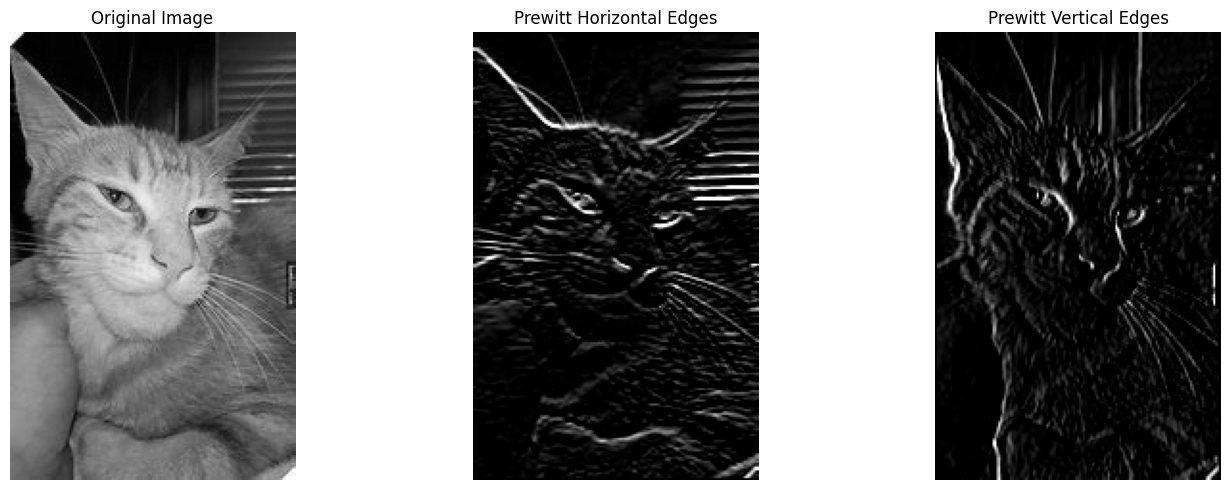

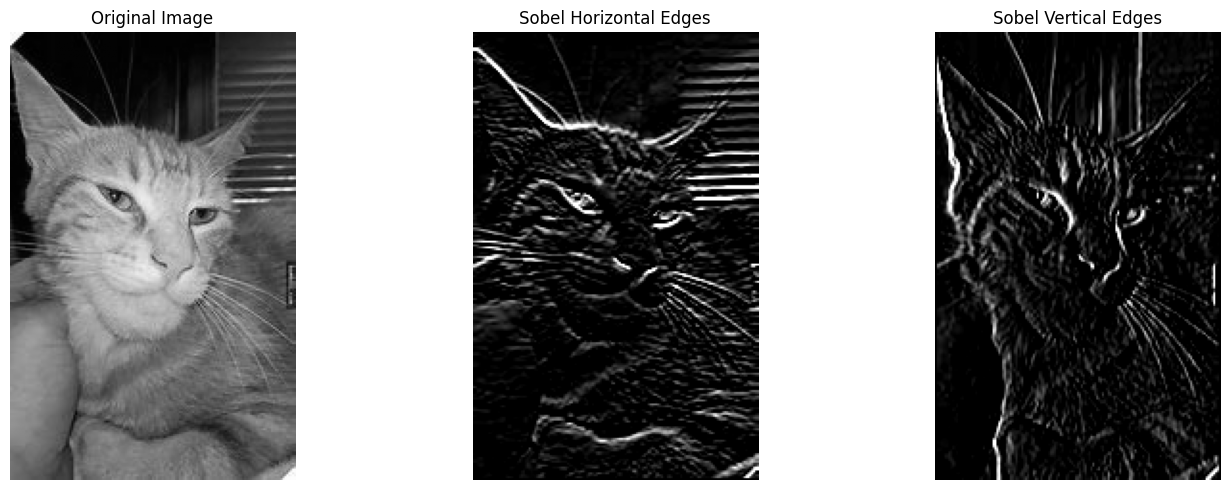

In [12]:
# Task 2: Implementation of Prewitt and Sobel Kernels for Edge Detection

# Define Prewitt kernels
prewitt_horizontal = np.array([[-1, -1, -1], 
                               [0, 0, 0], 
                               [1, 1, 1]])

prewitt_vertical = np.array([[-1, 0, 1], 
                             [-1, 0, 1], 
                             [-1, 0, 1]])

# Define Sobel kernels
sobel_horizontal = np.array([[-1, -2, -1], 
                             [0, 0, 0], 
                             [1, 2, 1]])

sobel_vertical = np.array([[-1, 0, 1], 
                           [-2, 0, 2], 
                           [-1, 0, 1]])

# Apply Prewitt kernels
prewitt_horizontal_edges = cv2.filter2D(img2, -1, prewitt_horizontal)
prewitt_vertical_edges = cv2.filter2D(img2, -1, prewitt_vertical)

# Apply Sobel kernels
sobel_horizontal_edges = cv2.filter2D(img2, -1, sobel_horizontal)
sobel_vertical_edges = cv2.filter2D(img2, -1, sobel_vertical)

# Display Prewitt results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(img2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(prewitt_horizontal_edges, cmap='gray')
plt.title('Prewitt Horizontal Edges')
plt.axis('off')

plt.subplot(133)
plt.imshow(prewitt_vertical_edges, cmap='gray')
plt.title('Prewitt Vertical Edges')
plt.axis('off')
plt.tight_layout()
plt.show()

# Display Sobel results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.imshow(img2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(132)
plt.imshow(sobel_horizontal_edges, cmap='gray')
plt.title('Sobel Horizontal Edges')
plt.axis('off')

plt.subplot(133)
plt.imshow(sobel_vertical_edges, cmap='gray')
plt.title('Sobel Vertical Edges')
plt.axis('off')
plt.tight_layout()
plt.show()

# Task III. Run and Compare Result

## Goal:
### A. Use your work on edge detection using Laplacian from the previous week
### B. Display six images in a figure (Original of 3, and each technique results)
### C. Tell what you notice about the difference between these three techniques

- **Prewitt**: Uses simple 3×3 kernels that are sensitive to horizontal and vertical edges separately. Less sensitive to noise but may miss subtle edge details.
- **Sobel**: Uses weighted kernels that emphasize the central pixels, making it more accurate than Prewitt for detecting diagonal edges and providing better noise suppression.
- **Laplacian**: Detects edges in all directions simultaneously using a second derivative approach, resulting in thinner edges but higher sensitivity to noise.

The comparison will help understand the strengths and limitations of each edge detection technique across different image characteristics.

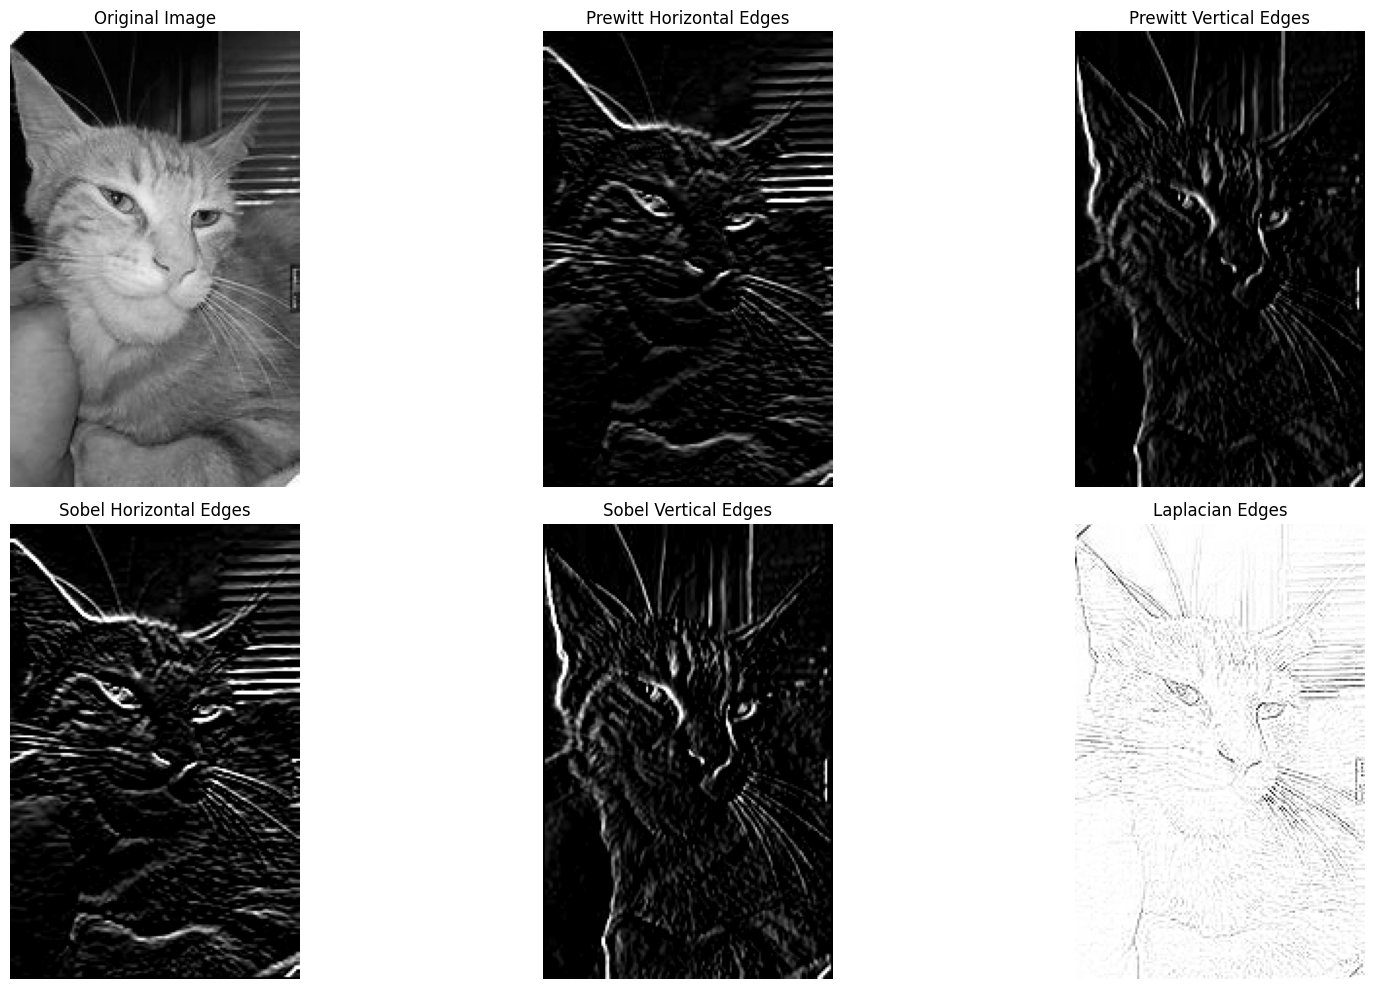

Comparison of Edge Detection Techniques:
-----------------------------------------
1. Prewitt: Simple kernel, detects edges in horizontal and vertical directions separately.
   - Less sensitive to noise but may miss subtle details
   - Lower computational complexity
   - Shows more gradual edge transitions

2. Sobel: Weighted kernel, emphasizes central pixels.
   - Better noise suppression than Prewitt
   - More accurate for diagonal edges
   - Produces stronger edge responses

3. Laplacian: Second-derivative operator, detects edges in all directions at once.
   - Produces thinner edge lines
   - More sensitive to noise
   - Better at identifying fine details and rapid intensity changes
   - Can detect zero crossings (important for edge localization)


In [13]:
# Task III: Compare Prewitt, Sobel, and Laplacian edge detection techniques

# Define Laplacian kernel
laplacian_kernel = np.array([[0, 1, 0],
                             [1, -4, 1],
                             [0, 1, 0]], dtype=np.float32)

# Apply Laplacian kernel for edge detection
laplacian_edges = cv2.filter2D(img2, -1, laplacian_kernel)
# Invert the Laplacian result for better visualization (edges are now bright)
laplacian_edges = 255 - laplacian_edges

# Create a figure with 6 subplots: original image and results from 3 edge detection techniques
plt.figure(figsize=(18, 10))

# Original image
plt.subplot(231)
plt.imshow(img2, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Prewitt edges
plt.subplot(232)
plt.imshow(prewitt_horizontal_edges, cmap='gray')
plt.title('Prewitt Horizontal Edges')
plt.axis('off')

plt.subplot(233)
plt.imshow(prewitt_vertical_edges, cmap='gray')
plt.title('Prewitt Vertical Edges')
plt.axis('off')

# Sobel edges
plt.subplot(234)
plt.imshow(sobel_horizontal_edges, cmap='gray')
plt.title('Sobel Horizontal Edges')
plt.axis('off')

plt.subplot(235)
plt.imshow(sobel_vertical_edges, cmap='gray')
plt.title('Sobel Vertical Edges')
plt.axis('off')

# Laplacian edges
plt.subplot(236)
plt.imshow(laplacian_edges, cmap='gray')
plt.title('Laplacian Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

# Compare the three techniques
print("Comparison of Edge Detection Techniques:")
print("-----------------------------------------")
print("1. Prewitt: Simple kernel, detects edges in horizontal and vertical directions separately.")
print("   - Less sensitive to noise but may miss subtle details")
print("   - Lower computational complexity")
print("   - Shows more gradual edge transitions")
print()
print("2. Sobel: Weighted kernel, emphasizes central pixels.")
print("   - Better noise suppression than Prewitt")
print("   - More accurate for diagonal edges")
print("   - Produces stronger edge responses")
print()
print("3. Laplacian: Second-derivative operator, detects edges in all directions at once.")
print("   - Produces thinner edge lines")
print("   - More sensitive to noise")
print("   - Better at identifying fine details and rapid intensity changes")
print("   - Can detect zero crossings (important for edge localization)")